# Lab: Multi-Class Classification

*In this lab, we will build a multi-class classification model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
> * **Business Context:** A botanical research institute has discovered that the *Iris-virginica* species possesses unique genetic properties that are valuable for developing new floral hybrids. The institute needs to collect pure samples of this species for their research.
> * **Business Problem:** The current process of identifying *Iris-virginica* relies on manual inspection, which is slow and costly. While [an initial proposal](../02_linear_and_logistic_regression/10_logistic_regression_lab.ipynb) was to build a simple binary classifier ("Is it Virginica?"), it has been determined that this is insufficient. A misclassification of another species (e.g., *Iris-setosa*) as *Iris-virginica* would contaminate the research samples, wasting significant time and resources. Therefore, the business needs a more precise system that can differentiate between all three species to ensure only pure *Iris-virginica* samples are selected.
> * **Project Goal:** To build a **multi-class classification model** that uses the physical measurements of an iris flower (sepal length, petal width, etc.) to automatically and accurately classify a specimen into one of the three distinct species: *Iris-setosa*, *Iris-versicolor*, or *Iris-virginica*.

---

> ### 📝 2. Analytic Approach Report (Summary)
> *   **Problem Type:** ***Supervised Multi-Class Classification***. The objective is no longer to predict a binary "yes/no" outcome but to assign each flower to one of three distinct and mutually exclusive categories (*Iris-setosa*, *Iris-versicolor*, or *Iris-virginica*).
> *   **Candidate Models:** To comprehensively evaluate the best approach for this new problem, we will implement and compare three distinct strategies:
>     1.  **Baseline (Native Multi-Class):** **Softmax Regression**. This is the natural extension of Logistic Regression for multi-class problems and will serve as our interpretable baseline.
>     2.  **Candidate 2 (Wrapper):** **One-vs-Rest (OvR) Classifier**. This strategy involves training one binary classifier for each class against all others.
>     3.  **Candidate 3 (Wrapper):** **One-vs-One (OvO) Classifier**. This strategy involves training a dedicated binary classifier for every possible pair of classes.
> *   **Evaluation Metrics:** Given the balanced nature of the Iris dataset and the need for high-confidence predictions, we will use a suite of metrics:
>     *   **Accuracy:** To provide a single, overall measure of the models' correctness.
>     *   **Confusion Matrix:** This is critical for visualizing the specific types of errors the model makes (e.g., how many *versicolor* samples are misclassified as *virginica*).
>     *   **Precision, Recall, and F1-Score (per class and weighted average):** To provide a nuanced evaluation of performance for each species and an aggregate score that accounts for class balance.
> *   **Validation Strategy:** The modeling process will involve splitting the data into training and testing sets (80/20 split) and applying **feature scaling** (`StandardScaler`), as the underlying linear models benefit from standardized features. The performance of all three candidate models will be compared on the held-out test set.

---

> ### 📝 3. Data Requirements Report (Summary)
> *   **Data Source:** The project will continue to use the classic `iris.csv` dataset, sourced from the Scikit-learn library (`sklearn.datasets.load_iris`), as established in the [previous lab](../02_linear_and_logistic_regression/10_logistic_regression_lab.ipynb). The dataset contains data on 150 iris flower samples.
> *   **Features (Independent Variables):** The features remain unchanged: `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` (all measurements in centimeters).
> *   **Target (Dependent Variable):** This is the key change from the previous analysis. The target variable is now the original multi-class `species` column (or `target` from the scikit-learn object), which contains three distinct classes: *setosa* (0), *versicolor* (1), and *virginica* (2). We will no longer be engineering a binary `is_virginica` variable.
> *   **Granularity & Privacy:** The data granularity remains at the individual flower specimen level. The dataset is a well-known, public, and anonymized benchmark, containing no sensitive or personally identifiable information (PII), so there are no privacy concerns.

---

## Stage 4: Data Collection
As usual, we start with importing the necessary libraries and configuring them.

In [49]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1. Extract
First, we **Extract** the data from its original source (`scikit-learn`) and store it in an untouched, "raw" format in the `/data/raw/` directory. This creates a perfect, versionable mirror of the source system at the time of collection.

> ⚠️ **Caution:** To follow best practices for reproducibility, we are re-extracting the data from scratch rather than using files from the previous lab. This ensures our project is self-contained.

In [50]:
# Extract data from the source system (scikit-learn)
raw_data = load_iris()
print(f"Data has been extracted from the source system as '{type(raw_data)}'")

# Create a DataFrame with the original, untouched column names
raw_df = pd.DataFrame(data=raw_data.data, columns=raw_data.feature_names)
raw_df['target'] = raw_data.target

# Define and create the raw data directory
raw_data_dir = Path("../data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the raw DataFrame
raw_data_path = raw_data_dir / "iris_raw_v1.csv"
raw_df.to_csv(raw_data_path, index=False)

print(f"Extracted dataset has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")
print(f"Raw, untouched data has been saved to: {raw_data_path}\n")
raw_df.head()

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'
Extracted dataset has 150 samples and 5 features, with 0 missing values out of 750.
Raw, untouched data has been saved to: ../data/raw/iris_raw_v1.csv



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 4.2. Transform
Now, we perform the **Transform** step. We load the raw data from `/data/raw/`, apply lightweight corrections like standardizing column names, and fix any obvious, rule-based data quality issues.

In [51]:
# Load the raw data we just saved
interim_df = pd.read_csv(raw_data_path)

# --- Standardization ---
# Standardize column names to snake_case
new_columns = [col.replace(' (cm)', '').replace(' ', '_') for col in interim_df.columns]
interim_df.columns = new_columns

# Add the human-readable class name for context
interim_df['class_name'] = raw_data.target_names[interim_df['target']]

# Convert `class_name` category
interim_df['class_name'] = pd.Categorical(interim_df['class_name'])

# Create lists for numerical column names for ease of verification and analysis
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# --- Comprehensive Data Quality Validation & Cleaning ---
print("--- Running Data Quality Validation & Cleaning Suite ---")

# Initialize a list to collect all validation error messages
validation_errors = []

# --- Rule 1 (Critical): All numerical columns must have positive values (Critical)
cols_with_non_positives = []

for col in numerical_cols:
    if (interim_df[col] <= 0).any():
        cols_with_non_positives.append(col)

# If the check fails, append a descriptive error message to our list        
if cols_with_non_positives:
    error_message = f"Rule 1 Failed: The following columns contain non-positive values: {cols_with_non_positives}"
    validation_errors.append(error_message)
else:
    print("✅ Rule 1 Passed: All measurement columns contain positive values.")

# --- Rule 2 (Critical): The target variable must only contain the expected classes (0, 1, 2). 
expected_classes = {0, 1, 2}
actual_classes = set(interim_df['target'].unique())

if not actual_classes.issubset(expected_classes):
    unexpected_classes = actual_classes - expected_classes
    error_message = f"Rule 2 Failed: Found unexpected classes {unexpected_classes} in 'target' column."
    validation_errors.append(error_message)
else:
    print("✅ Rule 2 Passed: 'target' column contains only valid classes.")

# --- Rule 3 (Not Critical): The Dataset should not have fully duplicated rows:
num_duplicates = interim_df.duplicated().sum()

if num_duplicates > 0:
    print(f"⚠️ Rule 3 Warning: Found and removed {num_duplicates} fully duplicated rows.")
    interim_df = interim_df.drop_duplicates()
else:
    print("✅ Rule 3 Passed: No fully duplicated rows found.")

# --- Final Assertion ---
# After running all checks, assert that the list of CRITICAL errors is empty.
if validation_errors:
    full_error_message = "Data Quality Validation Failed with the following errors:\n- " + "\n- ".join(validation_errors)
    raise AssertionError(full_error_message)

print("\nAll data quality checks passed and cleaning steps applied successfully.")

# --- Final Human-Readable Summary (Focused on Boundaries) ---
print("\n--- Min/Max Summary of Validated Numerical Data ---")
display(interim_df[numerical_cols].describe().loc[['min', 'max']])

# --- Final Shape Verification ---
print(f"\nShape of the final interim DataFrame: {interim_df.shape}")

--- Running Data Quality Validation & Cleaning Suite ---
✅ Rule 1 Passed: All measurement columns contain positive values.
✅ Rule 2 Passed: 'target' column contains only valid classes.
⚠️ Rule 3 Warning: Found and removed 1 fully duplicated rows.

All data quality checks passed and cleaning steps applied successfully.

--- Min/Max Summary of Validated Numerical Data ---


,sepal_length,sepal_width,petal_length,petal_width
min,4.3,2.0,1.0,0.1
max,7.9,4.4,6.9,2.5



Shape of the final interim DataFrame: (149, 6)


### 4.3. Load: Save the Interim Data
Now we save the cleaned, transformed DataFrame to the `/data/interim/` directory. This file now becomes the official, clean starting point for all analysis.

In [52]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "iris_multi-class_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification
Finally, let's perform a sanity check. We'll load the `interim` data we just created and verify its structure and content.

In [53]:
# Load the final interim data and verify its contents
iris_df = pd.read_parquet(interim_data_path)
print(f"Verification successful. The following DataFrame is ready for analysis with {iris_df.shape[0]} samples and {iris_df.shape[1]} features:")
iris_df.sample(5)

Verification successful. The following DataFrame is ready for analysis with 149 samples and 6 features:


,sepal_length,sepal_width,petal_length,petal_width,target,class_name
33,5.5,4.2,1.4,0.2,0,setosa
102,7.1,3.0,5.9,2.1,2,virginica
19,5.1,3.8,1.5,0.3,0,setosa
10,5.4,3.7,1.5,0.2,0,setosa
113,5.7,2.5,5.0,2.0,2,virginica



---

> ### 📝 4. Data Collection Report (Summary)
>
> The data collection stage was successfully executed, following a formal **Extract, Transform, Load (ETL)** process with an integrated data quality suite to ensure reproducibility and reliability.
>
> *   **Extract:** The raw Iris dataset was programmatically extracted from the Scikit-learn library. A perfect, versionable mirror of this source data, with its original schema, was saved as a CSV file to `/data/raw/iris_raw_v1.csv`.
>
> *   **Transform:** The raw data was loaded and standardized by converting column names to `snake_case`. A programmatic validation and cleaning suite was then executed to enforce key business rules:
>     1.  **Validation:** It confirmed that all measurement columns (`sepal_length`, etc.) contain only positive values.
>     2.  **Validation:** It confirmed that the `target` column contains only the expected classes (0, 1, 2). The script is designed to halt execution if these critical validation rules fail.
>     3.  **Cleaning:** It identified and automatically **removed 1 fully duplicated row**, logging this action as a warning.
>
> *   **Load:** After passing all quality checks and cleaning steps, the resulting DataFrame was saved as an efficient Parquet file to the project's analytical starting point: `/data/interim/iris_multi_class_interim_v1.parquet`.
>
> *   **Verification:** A final check confirmed that the interim Parquet file loads correctly, containing **149 unique rows and 6 columns**, and is ready for analysis.
>
> **Status:** The data collection stage is **complete**.

---

## Stage 5: Data Understanding
The goal of this stage is to conduct **Exploratory Data Analysis (EDA)** to develop a deep understanding of the data's content, quality, and structure. Through descriptive statistics and visualization, we will identify patterns, detect anomalies, and test initial hypotheses. 

### 5.1. Preparation for EDA
Let's perform final preparatory checks and minor adjustments to ensure the DataFrame is perfectly suited for the analysis ahead.

In [54]:
# Create a new DataFrame for EDA
iris_eda = iris_df.copy()

# Check the column_names to see whether we need them all, as well as whether the data types are suitable for EDA
display(iris_eda.dtypes)

print("iris_eda DataFrame is ready for EDA with all the needed columns and correct data types.")

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
target             int64
class_name      category
dtype: object

iris_eda DataFrame is ready for EDA with all the needed columns and correct data types.


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1. Numerical Features

In [55]:
# Generate the descriptive statistics for the numerical variables
stats_df = iris_eda[numerical_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
sepal_length,149.0,5.843624,0.830851,4.3,5.1,5.8,6.4,7.9,0.142181
sepal_width,149.0,3.059732,0.436342,2.0,2.8,3.0,3.3,4.4,0.142608
petal_length,149.0,3.748993,1.767791,1.0,1.6,4.3,5.1,6.9,0.471537
petal_width,149.0,1.194631,0.762622,0.1,0.3,1.3,1.8,2.5,0.638375


* 📌 The numerical summary reveals that petal measurements (`petal_length`, `petal_width`) are far more variable relative to their means (CV of 47% and 64%) than sepal measurements (CV of ~14%). This suggests petal dimensions differ more significantly across the flowers than sepal dimensions.

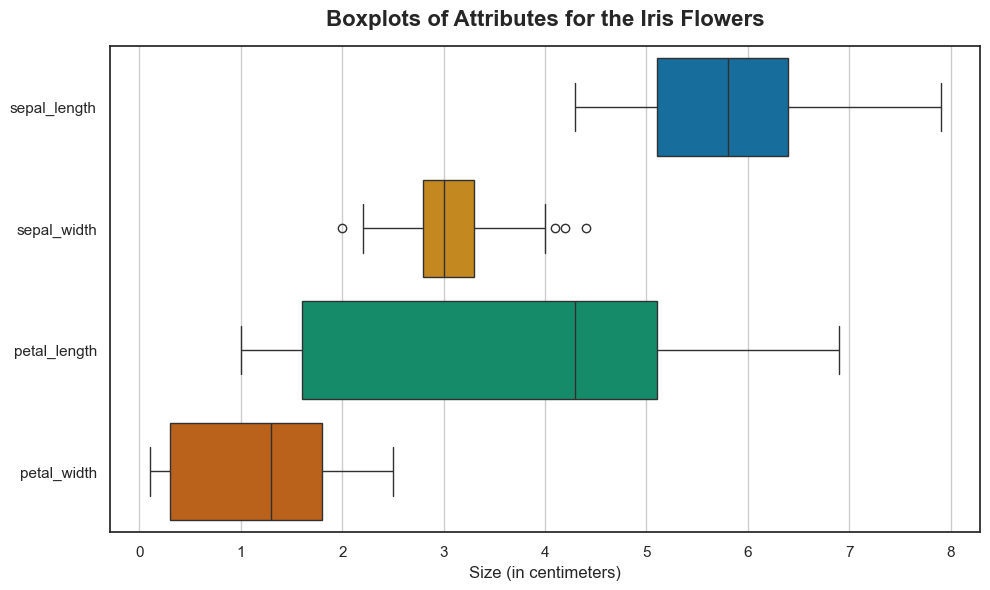

In [56]:
# Visualize the boxplots of numerical independent variables sharing the same units
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_eda[numerical_cols], orient="h")
plt.title("Boxplots of Attributes for the Iris Flowers", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Size (in centimeters)")
plt.grid(axis="x")
plt.show()

* 📌 The boxplots identified **4 potential outliers** in `sepal_width`, which appear to be natural variations rather than data entry errors.

#### 5.2.2. Categorical Features
Now let's take a look at the descriptive statistics for our categorical feature, `class_name`.

In [57]:
iris_eda['class_name'].value_counts()

class_name
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

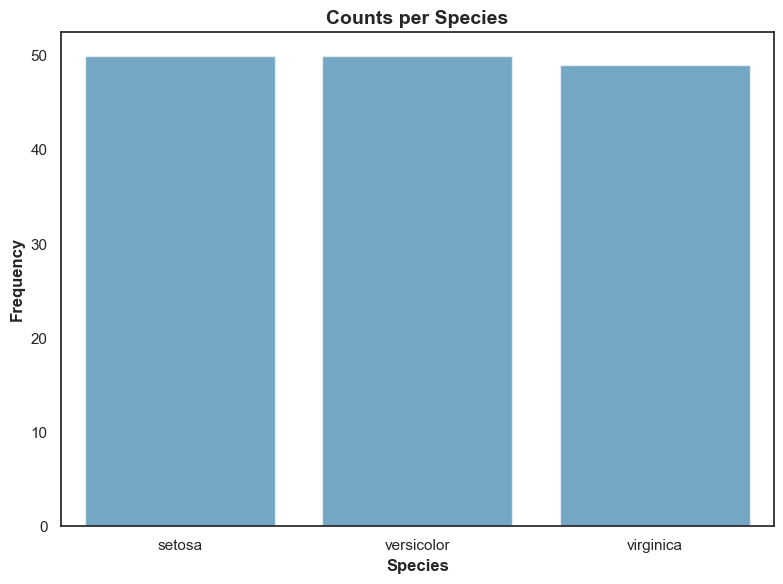

In [58]:
# Visualize the categorical column
plt.figure(figsize=(8, 6))
sns.countplot(iris_eda, x="class_name", alpha=0.6)
plt.title("Counts per Species", fontweight="bold", fontsize=14)
plt.xlabel("Species", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.tight_layout()
plt.show()

* 📌 The value counts table and count plot show that the dataset is almost perfectly balanced across the three species.

### 5.3. Univariate Analysis
Now it's time to analyze individual variables to understand their own distributions and characteristics.

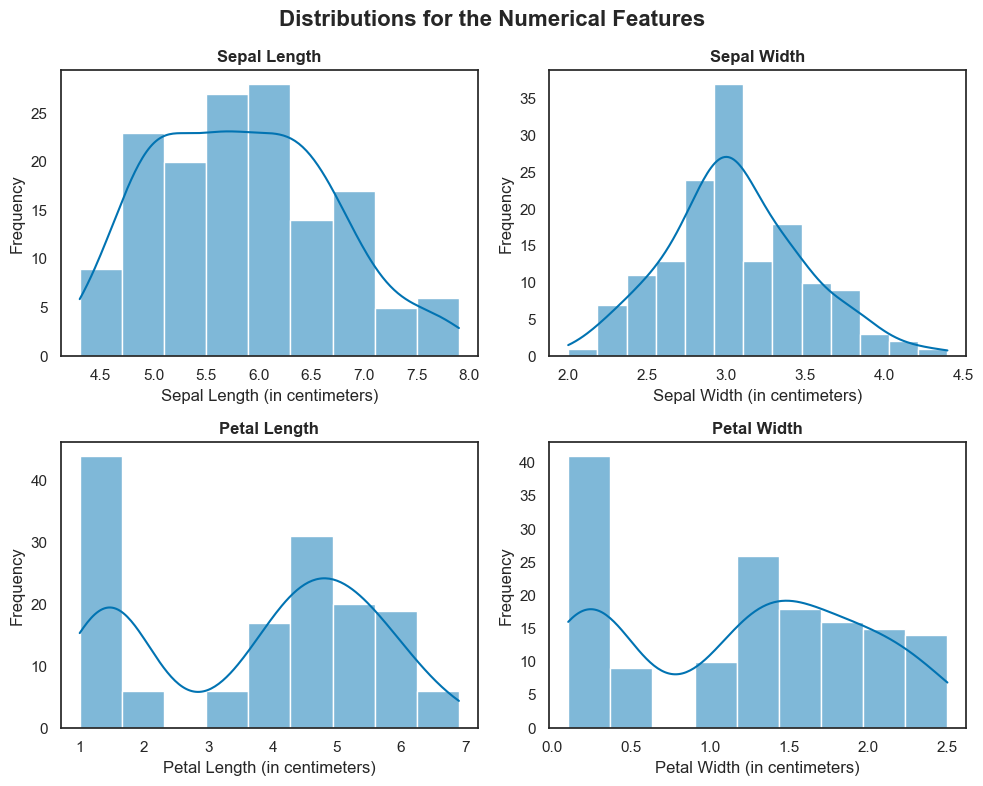

In [59]:
fig, axs = plt.subplots(2,2, figsize=(10, 8))
fig.suptitle("Distributions for the Numerical Features", fontweight="bold", fontsize=16)

sns.histplot(iris_df, x="sepal_length", ax=axs[0, 0], kde=True)
axs[0, 0].set_title("Sepal Length", fontweight="bold")
axs[0, 0].set_xlabel("Sepal Length (in centimeters)")
axs[0, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="sepal_width", ax=axs[0, 1], kde=True)
axs[0, 1].set_title("Sepal Width", fontweight="bold")
axs[0, 1].set_xlabel("Sepal Width (in centimeters)")
axs[0, 1].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_length", ax=axs[1, 0], kde=True)
axs[1, 0].set_title("Petal Length", fontweight="bold")
axs[1, 0].set_xlabel("Petal Length (in centimeters)")
axs[1, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_width", ax=axs[1, 1], kde=True)
axs[1, 1].set_title("Petal Width", fontweight="bold")
axs[1, 1].set_xlabel("Petal Width (in centimeters)")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

* 📌 `sepal_length` and `sepal_width` show roughly normal, unimodal (single-peaked) distributions.
* 📌 In contrast, `petal_length` and `petal_width` are strongly bimodal (double-peaked). This bimodal nature is a powerful signal, suggesting that these two features alone can create a very effective separation between at least two distinct groups of flowers, which will likely be very useful for our classification model.

### 5.4. Bivariate Analysis
Now let's analyze pairs of variables to investigate relationships and correlations. We'll start with the pair plot, and then use a correlation matrix to further investigate any multicollinearities.



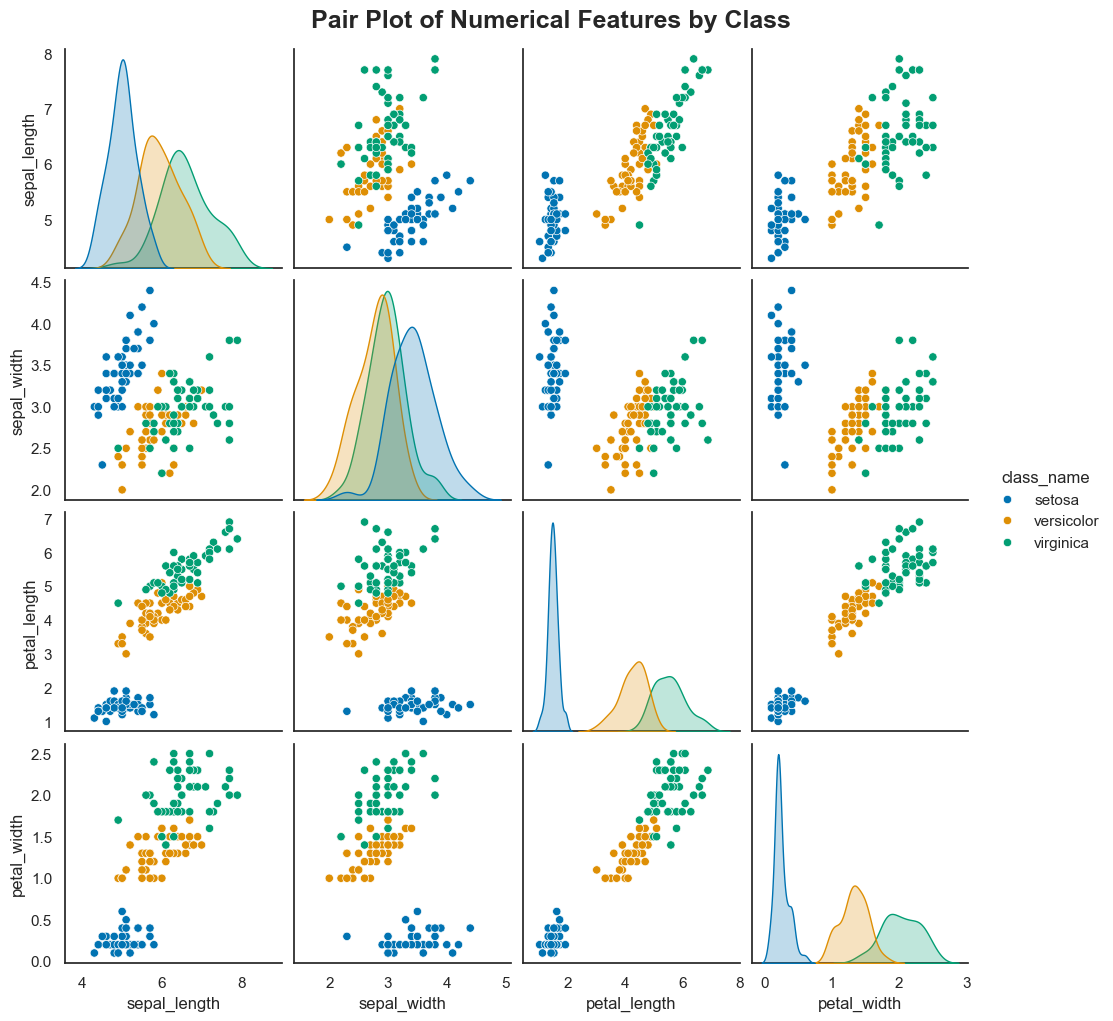

In [60]:
# Create a list of columns to use for the bivariate analysis
bivariate_cols = numerical_cols.copy()
bivariate_cols.append('class_name')

# Display the Pair Plot
pairplot = sns.pairplot(iris_eda[bivariate_cols], hue="class_name")
pairplot.figure.suptitle("Pair Plot of Numerical Features by Class", fontsize=18, fontweight="bold", y=1.02)
plt.show()

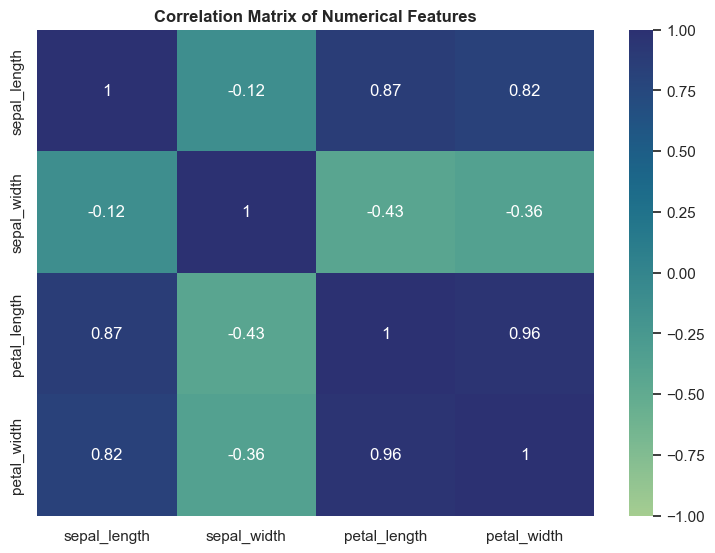

In [61]:
# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(iris_eda[numerical_cols].corr(), cmap='crest', annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features", fontweight="bold")
plt.show()

* 📌 Bivariate analysis strongly confirms the predictive power of petal measurements. The pair plot shows that `petal_length` and `petal_width` create a near-perfect linear separation between the classes.
* 📌 The correlation heatmap reveals a very strong positive correlation (0.96) between `petal_length` and `petal_width`, indicating significant **multicollinearity**. While this is a concern for interpreting coefficients in some linear models, it does not typically degrade the predictive accuracy of a multi-class classification model. The analysis confirms that these petal features are the most promising predictors for our model.

---

> ### 📝 5. Data Understanding Report (Summary)
>
> #### 🔍 Key Insights
>
> *   **Petal Dimensions are Powerfully Predictive:** The most significant finding from the EDA is that `petal_length` and `petal_width` are extremely strong predictors of the flower species. Their bimodal distributions and clear linear separability in the pair plots indicate they will be the most valuable features for the classification model.
> *   **Dataset is Well-Balanced:** The three target classes (`setosa`, `versicolor`, `virginica`) are almost perfectly balanced (50, 50, and 49 samples, respectively). This is a significant advantage, as it means we will not need to implement complex techniques to handle class imbalance during modeling.
>
> #### ⚠️ Data Quality Issues
>
> *   **Outliers Investigated:** Four potential outliers were identified in the `sepal_width` feature via boxplots. After visual inspection, these were deemed to be natural variations within the dataset and not data entry errors. They have been retained for the modeling stage.
> *   **Multicollinearity Noted:** A very high positive correlation (0.96) exists between `petal_length` and `petal_width`. While this multicollinearity would be a concern for an inferential linear model, it is not expected to negatively impact the predictive performance of the classification models we plan to use.

---

## Stage 6: Data Preparation

### 6.1. Data Cleaning
Since we've already confirmed that the data types of the columns are compatible with the modeling process, there are no outliers scheduled to be removed, and there are no missing values, there's no need for a data cleaning step.

### 6.2. Feature Engineering
Based on the insights from the Data Understanding stage, we will now engineer new features with two primary objectives:

1. **Address Multicollinearity:** To resolve the extreme correlation (0.96) between `petal_length` and `petal_width`, we will create a combined `petal_area` feature.
2. **Enhance Weak Predictors:** To attempt to extract more predictive signal from the individually weak sepal features, we will create a `sepal_ratio` feature that captures their shape relationship.

In [62]:
# Create new copy for data preparation
iris_processed = iris_eda.copy()

# Create new features
iris_processed['petal_area'] = iris_processed['petal_length'] * iris_processed['petal_width']
iris_processed['sepal_ratio'] = iris_processed['sepal_length'] / iris_processed['sepal_width']

# Display the DataFrame with the new features to verify
iris_processed.head()

,sepal_length,sepal_width,petal_length,petal_width,target,class_name,petal_area,sepal_ratio
0,5.1,3.5,1.4,0.2,0,setosa,0.28,1.457143
1,4.9,3.0,1.4,0.2,0,setosa,0.28,1.633333
2,4.7,3.2,1.3,0.2,0,setosa,0.26,1.468750
3,4.6,3.1,1.5,0.2,0,setosa,0.30,1.483871
4,5.0,3.6,1.4,0.2,0,setosa,0.28,1.388889


Let's also serialize this DataFrame with engineered features for later use:

In [63]:
# Define the directory path for our processed data
processed_data_dir = Path("../data/processed")
processed_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the prepared DataFrame using Parquet
processed_data_path = processed_data_dir / "iris_multi-class_processed_v1.parquet"
iris_processed.to_parquet(processed_data_path, index=False)

print(f"Processed data saved successfully to: {processed_data_path}")

Processed data saved successfully to: ../data/processed/iris_multi-class_processed_v1.parquet


### 6.3. Data Structuring and Final Selection
Now let's create our final DataFrame by selecting only the columns that will be used in the model.

In [64]:
# Define the final columns for our modeling dataset
final_cols = ['sepal_ratio', 'petal_area', 'target']

# Create the final DataFrame
final_df = iris_processed[final_cols]

# Display the head of the final DataFrame to verify
print("Final DataFrame ready for splitting:")
final_df.head()

Final DataFrame ready for splitting:


,sepal_ratio,petal_area,target
0,1.457143,0.28,0
1,1.633333,0.28,0
2,1.468750,0.26,0
3,1.483871,0.30,0
4,1.388889,0.28,0


### 6.4. Final Dataset Split
Let's separate the clean, prepared data into the final feature matrix (`X`) and target vector (`y`), and then perform the train-test split.

In [65]:
# Prepare the feature matrix and the target vector
X = final_df.drop(columns=['target'])
y = final_df['target']

# Final train-test split with stratification to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify the class distribution in the splits
print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Class distribution in y_train:
target
0    0.336134
1    0.336134
2    0.327731
Name: proportion, dtype: float64

Class distribution in y_test:
target
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64


### 6.5. Feature Scaling and Transformation
Since our predictors have different scales, we'll apply `StandardScaler` to our train and test sets.

In [66]:
# Initiate the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test set using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display the results to verify
print("Original X_train shape:", X_train.shape)
print("Scaled X_train shape:", X_train_scaled.shape)
print("\nFirst 5 rows of scaled training data (as a NumPy array):")
print(X_train_scaled[:5])

Original X_train shape: (119, 2)
Scaled X_train shape: (119, 2)

First 5 rows of scaled training data (as a NumPy array):
[[-1.46802523 -1.13133117]
 [ 0.78183287  1.25422777]
 [-0.14851386 -0.15943678]
 [-1.49416156 -1.05980647]
 [-0.99660771 -1.15236784]]



---

> ### 📝 6. Data Preparation Report (Summary)
> 
> #### Key Actions Performed
>
> *   **Feature Engineering:** Based on insights from EDA, two new features were engineered to create a more robust feature set:
>     1.  `petal_area`: Created by combining `petal_length` and `petal_width` to address their high multicollinearity.
>     2.  `sepal_ratio`: Created from `sepal_length` and `sepal_width` to potentially capture more predictive information about the flower's shape.
>     The resulting dataset with these new features was saved as a Parquet file to `/data/processed/` to preserve data types.
>
> *   **Final Feature Selection:** The final feature set for the model was selected, consisting of `petal_area` and `sepal_ratio`.
>
> *   **Dataset Splitting:** The final dataset was split into an 80% training set and a 20% testing set. Crucially, **stratification** was used to ensure that the distribution of the three target classes was identical in both the train and test sets, which is essential for reliable model evaluation.
>
> *   **Feature Scaling:** To prevent data leakage, the `StandardScaler` was **fit only on the training data** and was then used to transform both the training and testing sets.
>
> #### Key Outputs
>
> *   A final, pre-processed dataset containing engineered features, saved to `/data/processed/iris_multi_class_processed_v1.parquet`.
> *   Four final variables ready for modeling: `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test`.

---

## Stage 7: Modeling

### 7.1. Build and Train the Baseline and Candidate Models
As decided in the Analytic Approach stage, we will implement three models for multi-class classification:

1.  **Baseline (Native Multi-Class):** **Softmax Regression**. This is the natural extension of Logistic Regression for multi-class problems and will serve as our interpretable baseline.
2.  **Candidate 2 (Wrapper):** **One-vs-Rest (OvR) Classifier**. This strategy involves training one binary classifier for each class against all others.
3.  **Candidate 3 (Wrapper):** **One-vs-One (OvO) Classifier**. This strategy involves training a dedicated binary classifier for every possible pair of classes. Classifier**. This strategy involves training a dedicated binary classifier for every possible pair of classes.  

In [71]:
# Define the directory path for our models
models_dir = Path("../models")

# Create the directory if it doesn't exist
models_dir.mkdir(parents=True, exist_ok=True)

# Create and train the Softmax Regression baseline model
softmax_model = LogisticRegression(solver='lbfgs', random_state=42)
softmax_model.fit(X_train_scaled, y_train)

# Create and train the One-vs-Rest (OvR) Classifier
ovr_model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', random_state=42))
ovr_model.fit(X_train_scaled, y_train)

# Create and train the One-vs-One (OvO) Classifier
ovo_model = OneVsOneClassifier(LogisticRegression(solver='lbfgs', random_state=42))
ovo_model.fit(X_train_scaled, y_train)

# Save models + scaler + feature names
joblib.dump(softmax_model, models_dir / "softmax_regression_multi-class_iris_v1.joblib")
joblib.dump(ovr_model, models_dir / "ovr_classifier_multi-class_iris_v1.joblib")
joblib.dump(ovo_model, models_dir / "ovo_classifier_multi-class_iris_v1.joblib")
joblib.dump(scaler, models_dir / "standard_scaler_multi-class_iris_v1.joblib")
joblib.dump(list(X.columns), models_dir / "feature_names_multi-class_iris_v1.joblib")
print("Models and preprocessing artifacts saved.")

Models and preprocessing artifacts saved.



---

> ### 📝 7. Modeling Report (Summary)
> #### Models Implemented
> 1.  **Baseline Model:** A **Softmax Regression** model was implemented as the baseline. This model directly handles multi-class classification by estimating the probabilities of each class using the softmax function.
> 2.  **Candidate Model 2:** A **One-vs-Rest (OvR) Classifier** was implemented. This approach involves training a separate binary classifier for each class, where each classifier distinguishes one class from all others.
> 3.  **Candidate Model 3:** A **One-vs-One (OvO) Classifier** was implemented. This approach involves training a separate binary classifier for every possible pair of classes, resulting in multiple classifiers that vote on the final class prediction.

---

## Stage 8: Model Evaluation
Now that we have trained our three models, it's time to evaluate their performance on the held-out test set using the metrics defined in the Analytic Approach stage.

### 8.1. Evaluate Models on Test Set
Let's evaluate each model using accuracy, confusion matrix, precision, recall, and F1-score.

In [72]:
# Make predictions on the test set using all three models
y_pred_softmax = softmax_model.predict(X_test_scaled)
y_pred_ovr = ovr_model.predict(X_test_scaled)
y_pred_ovo = ovo_model.predict(X_test_scaled)

In [73]:
# Calculate evaluation metrics for each model
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

# Compile the results into a DataFrame for comparison
results = {
    'Model': ['Softmax Regression', 'One-vs-Rest Classifier', 'One-vs-One Classifier'],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for y_pred in [y_pred_softmax, y_pred_ovr, y_pred_ovo]:
    accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)

results_df = pd.DataFrame(results)
print("Model Evaluation Results:")
display(results_df)

Model Evaluation Results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Softmax Regression,0.900000,0.906061,0.900000,0.901504
1,One-vs-Rest Classifier,0.800000,0.814103,0.800000,0.798881
2,One-vs-One Classifier,0.933333,0.933333,0.933333,0.933333


* 📌 The best performing model was the One-vs-One (OvO) Classifier model. It achieved an overall accuracy of 93.33% on the held-out test set. The weighted precision, recall, and F1-score are all 93.33%, indicating strong, balanced performance across classes on the test split.
    * Precision = 0.9333 means that when the OvO model predicts a particular species, it is correct ~93.3% of the time.
    * Recall = 0.9333 means that the model correctly identifies ~93.3% of the actual samples of a given species.
    * F1-Score = 0.9333 (harmonic mean of precision and recall) confirms that the model achieves a good balance between avoiding false positives and avoiding false negatives across classes.

Let's now visualize the confusion matrix to better understand the performance of our model:

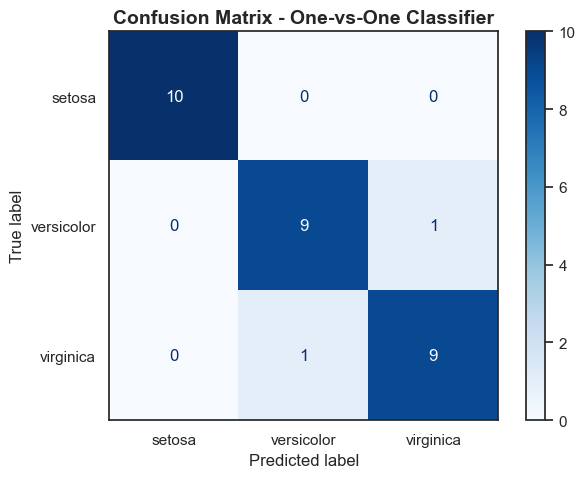

In [81]:
cm = confusion_matrix(y_test, y_pred_ovo, labels=ovo_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["setosa", "versicolor", "virginica"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - One-vs-One Classifier", fontweight="bold", fontsize=14)
plt.show()

* 📌 The confusion matrix shows the model predicts **setosa** perfectly. The main errors occur between **virginica** and **versicolor**:
  * About 1 in 10 virginica samples is misclassified as versicolor, and about 1 in 10 versicolor samples is misclassified as virginica.
  * Equivalently, of the flowers the model labels as versicolor, roughly 9 out of 10 are truly versicolor; and of those it labels as virginica, roughly 9 out of 10 are truly virginica.

### 8.2. Business Impact Analysis

#### 8.2.1 Summary of performance (OvO classifier)
* **Overall accuracy:** 93.33% (≈ 6.7 mistakes per 100 predictions).
* **Weighted precision / recall / F1:** ≈ 93.3% — balanced performance across classes.
* **Error pattern:** setosa is predicted perfectly; the remaining errors are concentrated between versicolor and virginica (≈ 1 in 10 versicolor ↔ virginica confusions).

#### 8.2.2 Operational implications
* High-confidence use for setosa:
    * Because setosa is classified with essentially 100% reliability, any automated actions that require high confidence (e.g., immediate routing, labeling, or downstream processing) can be performed without manual verification for items labeled setosa.
* Caution for versicolor / virginica decisions:
    * For the two hard-to-separate species, expect roughly a 10% substitution rate between them. In practice that means:
        * If you take 10 flowers the model calls virginica, about 9 are truly virginica.
        * If you take 10 true virginica flowers, the model will correctly identify ~9 of them and mislabel ~1 as versicolor.
    * If misclassifying these two species has asymmetric costs (e.g., virginica must not be missed because it is rare/valuable), operational safeguards are needed.

#### 8.2.3 Recommended business actions / deployment strategies
- Human-in-the-loop for borderline/expensive outcomes:
  - Automatically accept model labels for setosa.
  - For samples labeled versicolor or virginica, either (a) route a fraction to human review, or (b) apply a secondary (possibly more expensive or slower) verification step for high-cost decisions.
- Probability-thresholding & secondary checks:
  - Use model predicted probabilities to decide when to accept automatically vs. escalate. For example, accept automatic action only if model confidence ≥ 0.9; otherwise send to human review or a confirmatory classifier.
  - Optionally run a one-vs-rest binary check for a specific species of business interest (e.g., virginica) to boost recall/precision for that species at the cost of extra compute/complexity.
- Cost-sensitive decision policy:
  - Quantify the relative cost of false positives vs false negatives for each species and choose thresholds or post-processing policies that minimize expected business cost rather than raw error rate.
- Validation before full automation:
  - Perform stratified cross-validation and repeated-split experiments to estimate variability and upper/lower bounds on expected business errors before scaling the system.
- Monitoring, retraining & governance:
  - Log predictions, probabilities, and downstream decisions so you can track model drift and real-world error rates.
  - Set up periodic re-evaluation and retraining cadence (or trigger-based re-training) if the population or measurement process changes.
  - Maintain a rollback plan (human-only routing) in case performance degrades in production.

#### 8.2.4 Quick example: expected errors per 1,000 samples
- At ~93.3% accuracy → ~67 misclassifications per 1,000 samples.
- Because setosa errors ≈ 0, most of those ≈ 67 errors will be versicolor ↔ virginica swaps; if either species has higher business cost, plan mitigation accordingly.

#### 8.2.5 Conclusion / Recommendation
- The OvO model is a strong candidate for deployment when predictive performance is the primary goal.  
- For low-cost automated tasks (e.g., bulk tagging where occasional swaps are acceptable), the model can be used directly (with automatic acceptance for setosa).  
- For high-cost or safety-critical use cases involving virginica or versicolor, introduce calibrated confidence thresholds, human review for uncertain cases, or a secondary verification step to reduce the business risk from the ≈10% confusion between those two classes.

### 8.3. Final Model Review and Sign Off
* **Decision:** No-Go for immediate, final deployment.
* **Justification:**
    - The One-vs-One (OvO) classifier is the best-performing model on the held-out test split and is a strong candidate, but this single-split result is not sufficient to approve production deployment.
    - We have not yet applied best practices required for a robust selection (stratified cross-validation, hyperparameter tuning, probability calibration, and model stability checks).
    - The project plan explicitly calls for evaluating a broader set of candidate algorithms (e.g., K-Nearest Neighbors, Decision Trees, Random Forests / ensemble methods, and possibly gradient-boosted trees). These could outperform OvO or offer better trade-offs (interpretability, inference speed, calibration).
    - Therefore, we will retain the OvO model as the official baseline for comparison, but defer any final deployment decision until the comparative analysis and robustness checks are complete.
* **Approved status for baseline:** The OvO classifier is approved as the official baseline model for the next phase of experiments and comparisons.

---

> ### 📝 8. Evaluation Report (Summary)
> 
> **Model evaluated:** ovo_classifier_model_multi-class_iris_v1.joblib (One-vs-One logistic-regression ensemble)  
> 
> **Preprocessing artifact:** standard_scaler_v1.joblib (StandardScaler fitted on training data)  
> 
> **Test set performance (held-out 20%):**
> - Accuracy: 93.33%  
> - Weighted Precision: 93.33%  
> - Weighted Recall: 93.33%  
> - Weighted F1-Score: 93.33%
> 
> **Key observational insights:**
> - The OvO classifier is the top performer on the held-out test split, delivering strong and balanced predictive performance across the three species.
> - The confusion matrix shows perfect classification for setosa; remaining errors are concentrated between versicolor and virginica, with roughly a 1-in-10 substitution rate in each direction (i.e., about 10% of true virginica are predicted as versicolor and vice versa).
> - For predictions labeled versicolor or virginica, about 9 out of 10 are correct (positive predictive value ≈ 90% for each of those two classes).
> 
> **Business impact summary:**
> 
> - Operationally, setosa labels can be trusted for automatic actions without manual review due to essentially perfect classification performance for that class.
> - For versicolor and virginica, expect ≈10% confusion between them. If one species carries materially higher cost for misclassification (e.g., virginica has special value), introduce mitigations such as probability-thresholding, human-in-the-loop verification for uncertain predictions, or a secondary confirmatory check.
> - At the observed accuracy, anticipate roughly 67 misclassifications per 1,000 samples, mostly versicolor ↔ virginica swaps.
> 
> **Deployment decision:** No-Go for immediate, final deployment.
> 
> - Justification: Although the OvO classifier performed best on the single held-out split and is approved as the project’s official baseline for further experiments, we must not finalize deployment from a single-split result. Best-practice steps remain to be completed: stratified cross-validation for stability estimates, hyperparameter tuning, probability calibration, and comparison with additional candidate models (e.g., Decision Trees, KNN, Random Forests, gradient-boosted models). These steps could change the final selection or lead to model improvements that materially affect business risk.
> - Baseline status: The OvO model is approved as the official baseline for the next experimental phase (comparative modeling and robustness checks).
> 
> **Required next actions before final sign-off (summary):**
> 
> 1. Run stratified cross-validation (e.g., StratifiedKFold) to estimate mean ± std of accuracy and weighted F1.  
> 2. Evaluate additional candidate algorithms (KNN, Decision Trees, Random Forests, Gradient Boosting) with proper cross-validated hyperparameter tuning.  
> 3. Produce per-class reports and confusion matrices for all candidates; if necessary, implement cost-sensitive thresholds for operational deployment.  
> 4. Assess probability calibration if downstream decisions rely on predicted probabilities.  
> 5. Decide acceptance thresholds based on business cost trade-offs and implement monitoring/rollback and artifact/versioning for the selected model.
> 
> **Status:** Evaluation complete for the held-out test split. Proceeding to cross-validated comparative experiments and robustness checks before making a final deployment decision.

---

**Next:** [Decision Trees Theory](./08_decision_trees_theory.md)